In [3]:
import pandas as pd

# Load campaign performance data
df_ads = pd.read_csv(r'C:\Users\User\OneDrive\Documents\meta_ads_raw.csv')

# Load CRM customer data
df_crm = pd.read_csv(r'C:\Users\User\OneDrive\Documents\crm_customers.csv')

print("Ads shape:", df_ads.shape)
print("CRM shape:", df_crm.shape)

df_crm.head()

Ads shape: (16, 8)
CRM shape: (15, 9)


,customer_id,campaign_name,channel,age,gender,location,customer_type,purchase_value,purchase_date
0,C001,Summer Sale - Video,Meta,28,Female,Nairobi,New,4200,7/1/2024
1,C002,Retargeting - Dynamic,Meta,35,Male,Mombasa,Returning,8900,7/1/2024
2,C003,Summer Sale - Carousel,Meta,24,Female,Kisumu,New,2400,7/1/2024
3,C004,Brand Awareness - Video,Meta,42,Male,Nairobi,New,350,7/1/2024
4,C005,Retargeting - Dynamic,Meta,31,Female,Nakuru,Returning,9200,14/01/2024


In [ ]:
# Merge on campaign_name — connecting ad performance to customer behaviour
df_merged = pd.merge(df_ads, df_crm, on='campaign_name', how='left')

print("Merged shape:", df_merged.shape)
df_merged.head()

In [5]:
print("Columns after merge:")
print(df_merged.columns.tolist())

print("\nNulls after merge:")
print(df_merged.isnull().sum())

Columns after merge:
['campaign_name', 'channel_x', 'impressions', 'clicks', 'spend', 'conversions', 'revenue', 'date', 'customer_id', 'channel_y', 'age', 'gender', 'location', 'customer_type', 'purchase_value', 'purchase_date']

Nulls after merge:
campaign_name     0
channel_x         0
impressions       3
clicks            0
spend             0
conversions       3
revenue           0
date              0
customer_id       0
channel_y         0
age               0
gender            0
location          0
customer_type     0
purchase_value    0
purchase_date     0
dtype: int64


In [6]:
# Drop channel_y — we only need one channel column
df_merged = df_merged.drop(columns=['channel_y'])

# Rename channel_x back to channel
df_merged = df_merged.rename(columns={'channel_x': 'channel'})

print("Columns now:")
print(df_merged.columns.tolist())

Columns now:
['campaign_name', 'channel', 'impressions', 'clicks', 'spend', 'conversions', 'revenue', 'date', 'customer_id', 'age', 'gender', 'location', 'customer_type', 'purchase_value', 'purchase_date']


In [7]:
# Which campaign attracts the highest value customers?
campaign_value = df_merged.groupby('campaign_name').agg(
    avg_purchase_value=('purchase_value', 'mean'),
    total_purchase_value=('purchase_value', 'sum'),
    customer_count=('customer_id', 'count')
).round(2)

campaign_value.sort_values('avg_purchase_value', ascending=False)

,avg_purchase_value,total_purchase_value,customer_count
campaign_name,,,
Retargeting - Dynamic,9300.00,186000,20
Summer Sale - Video,4600.00,73600,16
Summer Sale - Carousel,2566.67,30800,12
Brand Awareness - Video,350.00,4200,12


In [8]:
# New vs Returning customers — who spends more?
customer_type = df_merged.groupby(['campaign_name', 'customer_type']).agg(
    avg_purchase=('purchase_value', 'mean'),
    count=('customer_id', 'count')
).round(2)

customer_type

avg_purchase  count
campaign_name           customer_type                     
Brand Awareness - Video New                   350.0     12
Retargeting - Dynamic   Returning            9300.0     20
Summer Sale - Carousel  New                  2500.0      8
                        Returning            2700.0      4
Summer Sale - Video     New                  4600.0     16

In [9]:
# New vs Returning customers — who spends more?
customer_type = df_merged.groupby(['campaign_name', 'customer_type']).agg(
    avg_purchase=('purchase_value', 'mean'),
    count=('customer_id', 'count')
).round(2)

customer_type


avg_purchase  count
campaign_name           customer_type                     
Brand Awareness - Video New                   350.0     12
Retargeting - Dynamic   Returning            9300.0     20
Summer Sale - Carousel  New                  2500.0      8
                        Returning            2700.0      4
Summer Sale - Video     New                  4600.0     16

In [10]:
# Which city drives the most value?
location_analysis = df_merged.groupby('location').agg(
    total_purchase=('purchase_value', 'sum'),
    avg_purchase=('purchase_value', 'mean'),
    customer_count=('customer_id', 'count')
).round(2)

location_analysis.sort_values('total_purchase', ascending=False)

,total_purchase,avg_purchase,customer_count
location,,,
Nairobi,129800,5408.33,24
Mombasa,66000,5500.00,12
Kisumu,59200,4933.33,12
Nakuru,39600,3300.00,12


In [11]:
output_path = r'C:\Users\User\OneDrive\Documents\marketing-analytics-python\outputs\wrangling_report.xlsx'

with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    df_merged.to_excel(writer, sheet_name='Merged Data', index=False)
    campaign_value.to_excel(writer, sheet_name='Campaign Value')
    customer_type.to_excel(writer, sheet_name='Customer Type')
    location_analysis.to_excel(writer, sheet_name='Location Analysis')

print("Module 2 report saved successfully.")

Module 2 report saved successfully.


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

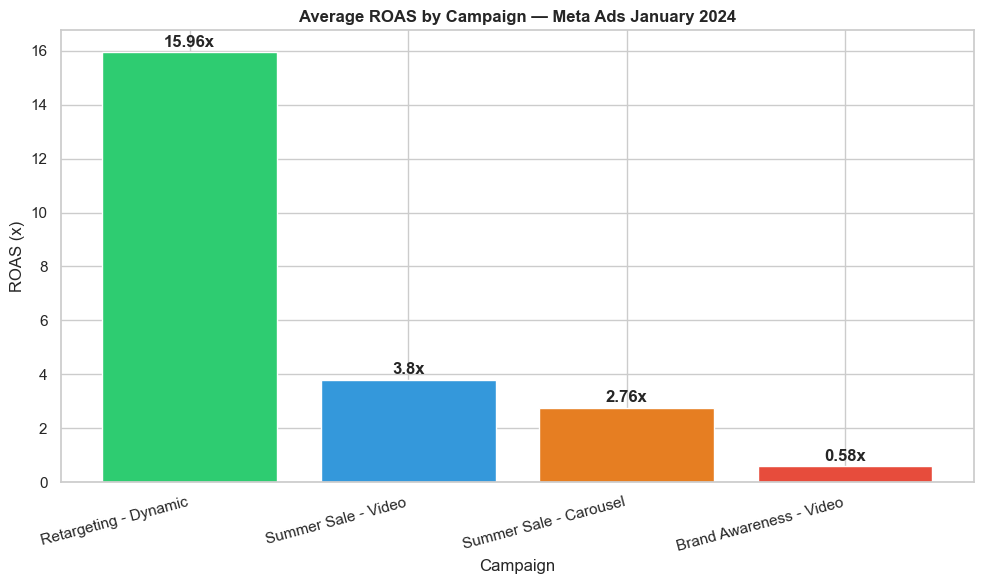

Chart 1 saved.


In [19]:
import os

# Create outputs folder if it doesn't exist
os.makedirs(r'C:\Users\User\OneDrive\Documents\marketing-analytics-python\outputs', exist_ok=True)

# Define output path
output_path = r'C:\Users\User\OneDrive\Documents\marketing-analytics-python\outputs'

# Recalculate ROAS on merged data
df_merged['ROAS'] = (df_merged['revenue'] / df_merged['spend']).round(2)

# Group by campaign
roas_data = df_merged.groupby('campaign_name')['ROAS'].mean().round(2)
roas_data = roas_data.sort_values(ascending=False)

# Plot
fig, ax = plt.subplots()
bars = ax.bar(range(len(roas_data)), roas_data.values, 
              color=['#2ecc71','#3498db','#e67e22','#e74c3c'])
ax.set_title('Average ROAS by Campaign — Meta Ads January 2024', fontweight='bold')
ax.set_xlabel('Campaign')
ax.set_ylabel('ROAS (x)')
ax.set_xticks(range(len(roas_data)))
ax.set_xticklabels(roas_data.index, rotation=15, ha='right')

# Add value labels on bars
for bar, val in zip(bars, roas_data.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val}x', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(output_path, 'chart1_roas_by_campaign.png'), dpi=150)
plt.show()
print("Chart 1 saved.")

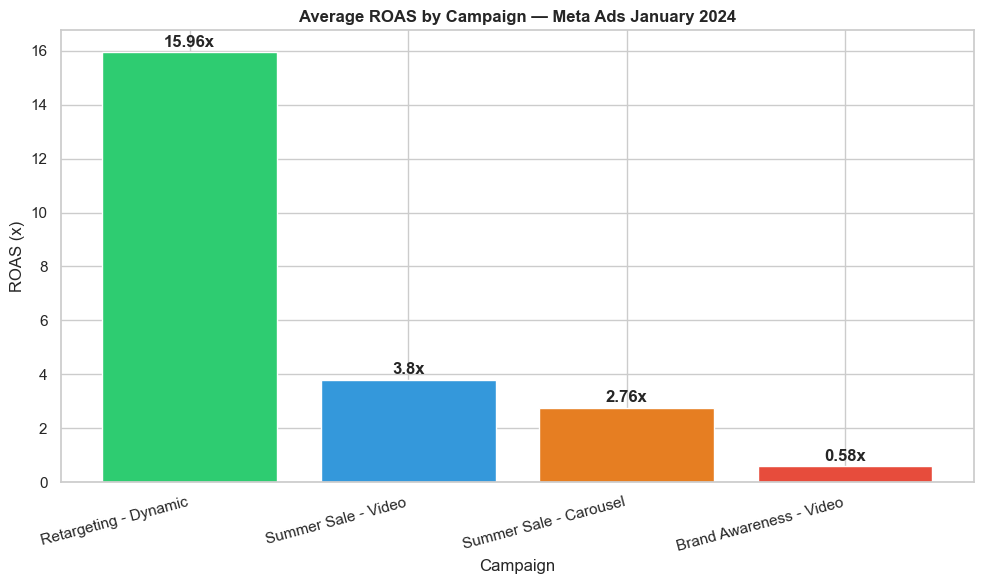

Chart 1 saved.


In [21]:
# Recalculate ROAS on merged data
df_merged['ROAS'] = (df_merged['revenue'] / df_merged['spend']).round(2)

# Group by campaign
roas_data = df_merged.groupby('campaign_name')['ROAS'].mean().round(2)
roas_data = roas_data.sort_values(ascending=False)

# Plot
fig, ax = plt.subplots()
bars = ax.bar(range(len(roas_data)), roas_data.values,
              color=['#2ecc71','#3498db','#e67e22','#e74c3c'])
ax.set_title('Average ROAS by Campaign — Meta Ads January 2024', fontweight='bold')
ax.set_xlabel('Campaign')
ax.set_ylabel('ROAS (x)')
ax.set_xticks(range(len(roas_data)))
ax.set_xticklabels(roas_data.index, rotation=15, ha='right')

# Add value labels on bars
for bar, val in zip(bars, roas_data.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val}x', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(output_path, 'chart1_roas_by_campaign.png'), dpi=150)
plt.show()
print("Chart 1 saved.")

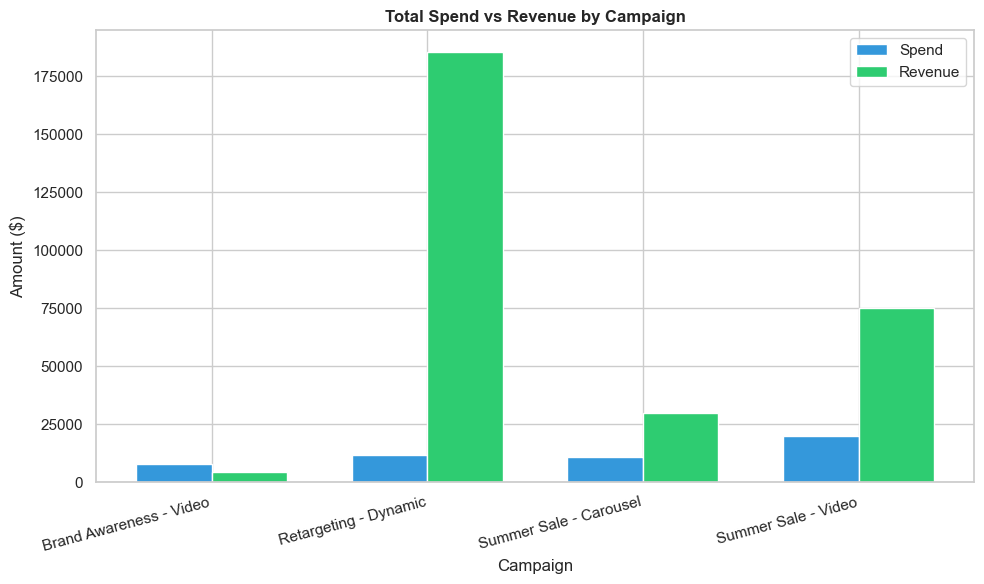

Chart 2 saved.


In [22]:
spend_revenue = df_merged.groupby('campaign_name').agg(
    total_spend=('spend', 'sum'),
    total_revenue=('revenue', 'sum')
).round(2)

x = range(len(spend_revenue))
width = 0.35

fig, ax = plt.subplots()
ax.bar([i - width/2 for i in x], spend_revenue['total_spend'],
       width, label='Spend', color='#3498db')
ax.bar([i + width/2 for i in x], spend_revenue['total_revenue'],
       width, label='Revenue', color='#2ecc71')

ax.set_title('Total Spend vs Revenue by Campaign', fontweight='bold')
ax.set_xlabel('Campaign')
ax.set_ylabel('Amount ($)')
ax.set_xticks(x)
ax.set_xticklabels(spend_revenue.index, rotation=15, ha='right')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(output_path, 'chart2_spend_vs_revenue.png'), dpi=150)
plt.show()
print("Chart 2 saved.")

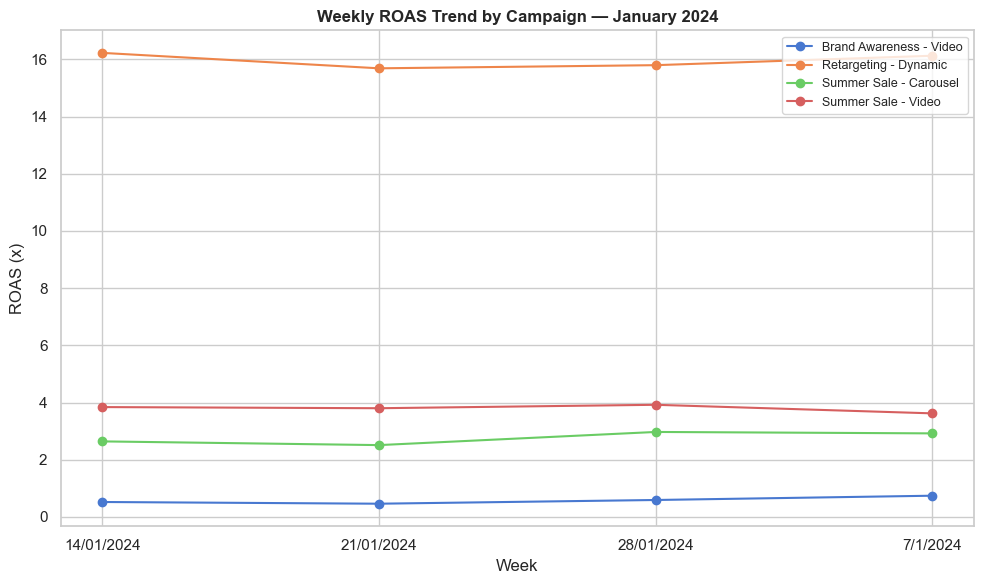

Chart 3 saved.


In [31]:
# Fix date ordering on Chart 3
weekly_roas = df_merged.groupby(
    ['date', 'campaign_name'])['ROAS'].mean().reset_index()

# Sort by date properly
weekly_roas = weekly_roas.sort_values('date')

fig, ax = plt.subplots()
for campaign in weekly_roas['campaign_name'].unique():
    data = weekly_roas[weekly_roas['campaign_name'] == campaign]
    ax.plot(data['date'], data['ROAS'], marker='o', label=campaign)

ax.set_title('Weekly ROAS Trend by Campaign — January 2024', fontweight='bold')
ax.set_xlabel('Week')
ax.set_ylabel('ROAS (x)')
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(output_path, 'chart3_weekly_roas_trend.png'), dpi=150)
plt.show()
print("Chart 3 saved.")

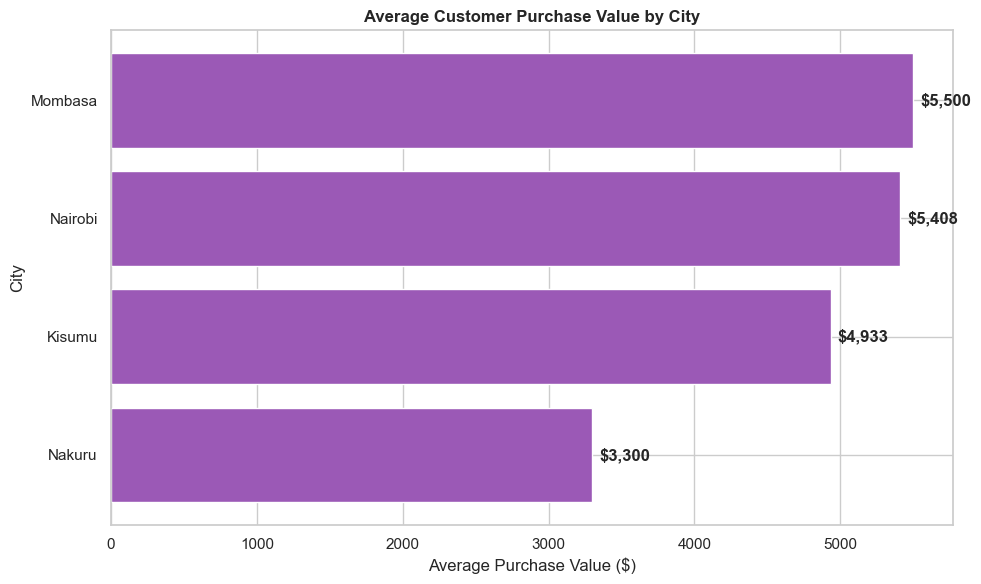

Chart 4 saved.


In [27]:
location_data = df_merged.groupby('location')['purchase_value'].mean().round(2)
location_data = location_data.sort_values(ascending=True)

fig, ax = plt.subplots()
ax.barh(range(len(location_data)), location_data.values, color='#9b59b6')
ax.set_title('Average Customer Purchase Value by City', fontweight='bold')
ax.set_xlabel('Average Purchase Value ($)')
ax.set_ylabel('City')
ax.set_yticks(range(len(location_data)))
ax.set_yticklabels(location_data.index)

for i, val in enumerate(location_data.values):
    ax.text(val + 50, i, f'${val:,.0f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(output_path, 'chart4_purchase_by_location.png'), dpi=150)
plt.show()
print("Chart 4 saved.")

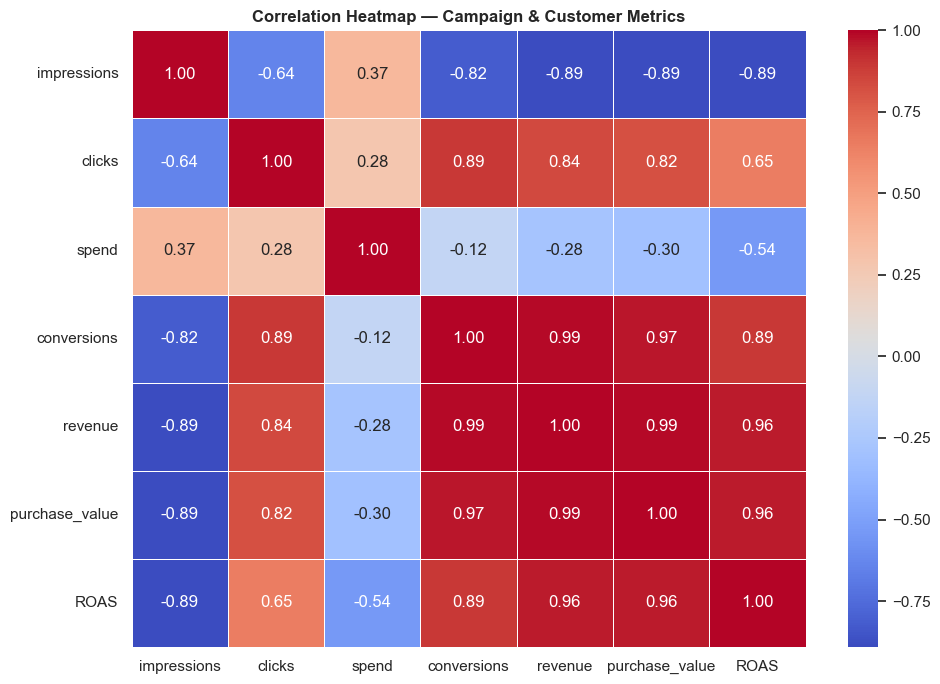

Chart 5 saved.


In [29]:
# Select and clean numeric columns for correlation
numeric_cols = df_merged[['impressions', 'clicks', 'spend',
                           'conversions', 'revenue', 'purchase_value', 'ROAS']].copy()

# Force all columns to numeric — handles any lingering non-numeric values
numeric_cols = numeric_cols.apply(pd.to_numeric, errors='coerce')

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(numeric_cols.corr().round(2),
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidths=0.5,
            ax=ax)
ax.set_title('Correlation Heatmap — Campaign & Customer Metrics', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(output_path, 'chart5_correlation_heatmap.png'), dpi=150)
plt.show()
print("Chart 5 saved.")